In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

class DropoutLayer(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        mask = (torch.rand_like(x) > self.p).float()
        return x * mask / (1 - self.p)

# 1. Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std (single channel)
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 2. Balanced subset — 500 per class = 5000 train, 100 per class = 1000 test
def balanced_subset(dataset, samples_per_class):
    targets = np.array(dataset.targets)
    indices = []
    for cls in range(10):
        cls_indices = np.where(targets == cls)[0]
        indices.extend(cls_indices[:samples_per_class].tolist())
    return Subset(dataset, indices)

train_dataset = balanced_subset(train_dataset, samples_per_class=100)
test_dataset  = balanced_subset(test_dataset,  samples_per_class=100)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

histories = {}
configs = [
    {"name": "No Dropout, 1 Layer",  "dropout_rate": 0.0, "hidden_layers": 1},
    {"name": "No Dropout, 3 Layers", "dropout_rate": 0.0, "hidden_layers": 3},
    {"name": "No Dropout, 5 Layers", "dropout_rate": 0.0, "hidden_layers": 5},
    {"name": "No Dropout, 10 Layers", "dropout_rate": 0.0, "hidden_layers": 10},
    {"name": "Dropout 0.5, 1 Layer",  "dropout_rate": 0.5, "hidden_layers": 1},
    {"name": "Dropout 0.5, 3 Layers", "dropout_rate": 0.5, "hidden_layers": 3},
    {"name": "Dropout 0.5, 5 Layers", "dropout_rate": 0.5, "hidden_layers": 5},
    {"name": "Dropout 0.5, 10 Layers", "dropout_rate": 0.5, "hidden_layers": 10},
]

for cfg in configs:
    dropout_rate  = cfg["dropout_rate"]
    hidden_layers = cfg["hidden_layers"]
    config_name = cfg["name"]
    print(f"\n--- Training Model | {config_name} ---")
    torch.manual_seed(42)

    conv_layer_dropout = min(0.2, dropout_rate)

    # Conv backbone — fixed regardless of config
    layers = [
        nn.Conv2d(1, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        DropoutLayer(p=conv_layer_dropout),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        DropoutLayer(p=conv_layer_dropout),

        nn.Flatten(),
    ]


    for _ in range(hidden_layers):
        layers += [
            nn.Linear(6272, 6272),
            nn.ReLU(),
            DropoutLayer(p=dropout_rate),
        ]


    layers += [
        nn.Linear(6272, 10),
    ]

    model = nn.Sequential(*layers).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epoch_ticks = []
    train_accuracies = []
    test_accuracies = []

    epochs = 50
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            correct, total = 0, 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                _, predicted = torch.max(model(images), 1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)
            train_acc = correct / total

            correct, total = 0, 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                _, predicted = torch.max(model(images), 1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)
            test_acc = correct / total

        epoch_ticks.append(epoch + 1)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc*100:.1f}% | Test Acc: {test_acc*100:.1f}%")

    histories[config_name] = {
        'ticks': epoch_ticks,
        'train': train_accuracies,
        'test': test_accuracies
    }



Using device: cuda

--- Training Model | No Dropout, 1 Layer ---
Epoch [1/50] | Train Acc: 46.6% | Test Acc: 39.4%
Epoch [2/50] | Train Acc: 80.9% | Test Acc: 74.9%
Epoch [3/50] | Train Acc: 85.2% | Test Acc: 75.9%
Epoch [4/50] | Train Acc: 91.1% | Test Acc: 85.4%
Epoch [5/50] | Train Acc: 94.5% | Test Acc: 87.5%
Epoch [6/50] | Train Acc: 96.2% | Test Acc: 91.3%
Epoch [7/50] | Train Acc: 97.7% | Test Acc: 91.5%
Epoch [8/50] | Train Acc: 99.1% | Test Acc: 92.5%
Epoch [9/50] | Train Acc: 98.8% | Test Acc: 93.2%
Epoch [10/50] | Train Acc: 99.4% | Test Acc: 93.2%
Epoch [11/50] | Train Acc: 99.8% | Test Acc: 93.5%
Epoch [12/50] | Train Acc: 99.9% | Test Acc: 94.0%
Epoch [13/50] | Train Acc: 100.0% | Test Acc: 94.2%
Epoch [14/50] | Train Acc: 100.0% | Test Acc: 93.9%
Epoch [15/50] | Train Acc: 100.0% | Test Acc: 93.7%
Epoch [16/50] | Train Acc: 100.0% | Test Acc: 93.9%
Epoch [17/50] | Train Acc: 100.0% | Test Acc: 94.3%
Epoch [18/50] | Train Acc: 100.0% | Test Acc: 94.8%
Epoch [19/50] | Trai

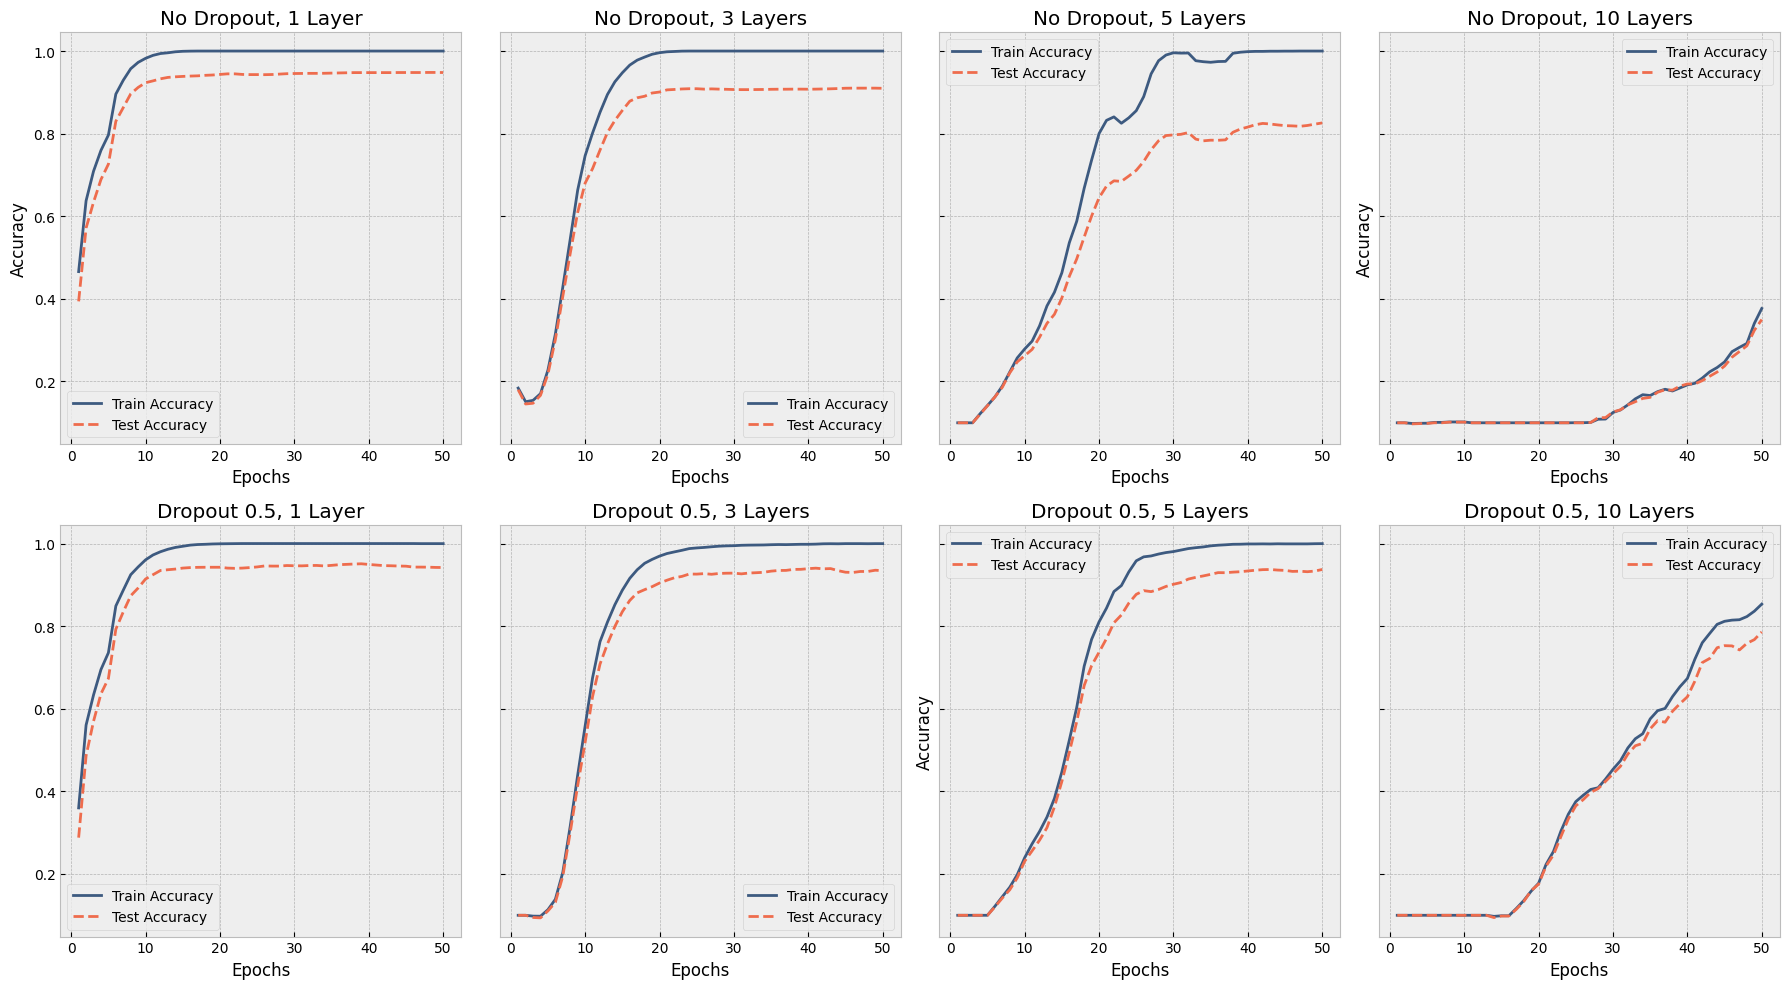

In [13]:
# # 3. Plot
plt.style.use('bmh')
colors = ["#3d5a80", "#ee6c4d"]
window_size = 5

fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for idx, cfg in enumerate(configs):
    ax = axes[idx]
    hist = histories[cfg['name']]

    smooth_train = pd.Series(hist['train']).rolling(window=window_size, min_periods=1).mean()
    smooth_test  = pd.Series(hist['test']).rolling(window=window_size, min_periods=1).mean()

    ax.plot(hist['ticks'], smooth_train, label='Train Accuracy', color=colors[0], linewidth=2)
    ax.plot(hist['ticks'], smooth_test,  label='Test Accuracy',  color=colors[1], linewidth=2, linestyle='--')

    ax.set_title(cfg['name'])
    ax.set_xlabel('Epochs')
    if idx % 3 == 0:        # left column: indices 0 and 3
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('dropout_training.png')
plt.show()